### Forecasting Noise Patterns

Now for the moment of truth. We’re taking our model and using three years of historical data (2021–2024) to predict how noise complaint variability shifts across different NYC NTAs.

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import random
from datetime import date, timedelta
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import geopandas as gpd
from keplergl import KeplerGl
from helpers import ( 
                        prep_the_data, 
                       export_geo_kepler, 
                      make_daily_table_for_model_with_nta,
                        make_typical_week_2025,
                      make_daily_observed_2025,
                      load_idata,
                      kepler_typical_week_from_dow_complaint,
                      random_summer_date,
                      summarize_lam_posterior,
                    )




### Load + prepare data: 2021-2024 

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()


In [6]:
df_puma_2021__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0303,0.403905,East Village,East Village — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2021-07-10,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2021,Animal,ANIMAL__Saturday
2,4103,Noise,"Noise, Barking Dog",NaN,2021-08-07,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2021,Animal,ANIMAL__Saturday
3,4103,Noise,"Noise, Barking Dog",NaN,2021-08-13,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2021,Animal,ANIMAL__Friday
4,4103,Noise,"Noise, Barking Dog",NaN,2021-08-15,night,2,MN0303,0.403905,East Village,East Village — 4103,Sunday,August,1,August__2021,Animal,ANIMAL__Sunday


#### We’re going to focus on Social/Party complaints, since they consistently show up as the largest share of noise complaints in the data.

In [7]:
COMPLAINT = "Social / Party"
# COMPLAINT = "Animal"
# COMPLAINT = "Construction / Industrial"
# COMPLAINT = "Mechanical Equipment"

# Rebuild daily_df_train exactly as in training
daily_df_train, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_value=COMPLAINT,
)



In [8]:
# Rebuild nta -> puma mapping
nta_puma_map = (
    daily_df_train[["nta_idx", "puma_idx"]]
    .drop_duplicates()
    .sort_values("nta_idx")
)


In [9]:

nta_to_puma_idx = nta_puma_map["puma_idx"].to_numpy()


### Load Model 3

In [10]:
idata_nta_puma_pois = load_idata("../data/processed/models/model3_partially_pooled_nta_puma_grouped_idata.nc")

✅ Loaded idata <- ../data/processed/models/model3_partially_pooled_nta_puma_grouped_idata.nc


WE begin by building the posterior 

In [11]:
df_forecast = summarize_lam_posterior(idata_nta_puma_pois, "lam_forecast")
lam_post = idata_nta_puma_pois.posterior["lam"]


We calculate the 90% HDI (Highest Density Interval) to capture the plausible range 
of expected noise complaints for each NTA and day of week.

In practical terms, this gives us the lower and upper bounds — the minimum and maximum complaint 
counts we’d reasonably expect, given the posterior distribution.

In [12]:
df_forecast.head()


,nta,dow,lam_forecast,lam_forecast_high_90,lam_forecast_low_90,lam_forecast_width_90
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.767475,7.453449,6.029359,1.424091
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.246580,8.995852,7.521392,1.474461
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,8.136387,8.882789,7.371348,1.511441
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.377994,9.063577,7.582603,1.480974
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.687496,10.448317,8.939294,1.509023


### Load Complaints from the summer of 2025

In [13]:
df_puma_311_2025 = df_puma.loc[
    (df_puma["created_bucket"] >= "2025-01-01") 
    & (df_puma["descriptor_group"] ==  COMPLAINT)
#    & (df_puma["time_of_day"] ==  "night")
].copy()


In [14]:
df_puma_311_2025.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
958,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-07-12,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2025,Social / Party,SOCIAL_PARTY__Saturday
959,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-07-15,night,1,MN0303,0.403905,East Village,East Village — 4103,Tuesday,July,0,July__2025,Social / Party,SOCIAL_PARTY__Tuesday
960,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-01,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2025,Social / Party,SOCIAL_PARTY__Friday
961,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-11,night,1,MN0303,0.403905,East Village,East Village — 4103,Monday,August,0,August__2025,Social / Party,SOCIAL_PARTY__Monday
962,4103,Noise - Commercial,Car/Truck Music,Store/Commercial,2025-08-16,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2025,Social / Party,SOCIAL_PARTY__Saturday


### Aggregate noise complaints for a typical week in the summer week per NTA.

In [15]:
typical_2025 = make_typical_week_2025(
    df_puma_311_2025,
    complaint_col="descriptor_group",
    months = [6, 7, 8],
    geo_col="nta_name",
)


### Compare Forecasted data to Observed 2025 data for a typical week

In [16]:

# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,
    complaint_col="descriptor_group",
    geo_col="nta_name",
    label_col="nta_puma",
)



In [17]:
# -----------------------------
# 1) Merge forecast (keyed by nta,dow)
# -----------------------------
forecast = df_forecast_week if "df_forecast_week" in globals() else df_forecast
forecast = forecast.rename(columns={"nta": "geo"}) if "nta" in forecast.columns else forecast

daily_cmp_2025_model2 = daily_2025.merge(
    forecast,
    on=["geo", "dow"],
    how="left",
)

# -----------------------------
# 2) Point forecast errors
# -----------------------------
daily_cmp_2025_model2["error"] = (
    daily_cmp_2025_model2["daily_count"] - daily_cmp_2025_model2["lam_forecast"]
)
daily_cmp_2025_model2["abs_error"] = daily_cmp_2025_model2["error"].abs()

# Optional: keep lam-interval coverage for reference only.
# IMPORTANT: lam_low_90 / lam_high_90 are intervals for the latent mean rate λ,
# not for realized daily counts. They should NOT be expected to achieve ~90%
# coverage for observed counts.
if {"lam_low_90", "lam_high_90"}.issubset(daily_cmp_2025_model2.columns):
    daily_cmp_2025_model2["within_90_lam"] = (
        (daily_cmp_2025_model2["daily_count"] >= daily_cmp_2025_model2["lam_low_90"]) &
        (daily_cmp_2025_model2["daily_count"] <= daily_cmp_2025_model2["lam_high_90"])
    )
else:
    daily_cmp_2025_model2["within_90_lam"] = pd.NA

# -----------------------------
# 3) Build nta_idx / dow_idx aligned to training coords
# -----------------------------
nta_to_idx = {str(n): i for i, n in enumerate(coords["nta"])}
dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

daily_cmp_2025_model2["nta_idx"] = daily_cmp_2025_model2["geo"].astype(str).map(nta_to_idx)
daily_cmp_2025_model2["dow_idx"]  = daily_cmp_2025_model2["dow"].astype(str).map(dow_to_idx)

daily_cmp_2025_model2 = daily_cmp_2025_model2.dropna(subset=["nta_idx", "dow_idx"]).copy()
daily_cmp_2025_model2["nta_idx"] = daily_cmp_2025_model2["nta_idx"].astype(int)
daily_cmp_2025_model2["dow_idx"]  = daily_cmp_2025_model2["dow_idx"].astype(int)

# -----------------------------
# 4) Posterior predictive draws for Model 3 (partially pooled NTA | PUMA grouped)
# -----------------------------
lam_draws_m2 = (
    idata_nta_puma_pois.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .transpose("nta", "dow", "sample")
    .values
)  # (n_nta, n_dow, S)

n_idx = daily_cmp_2025_model2["nta_idx"].to_numpy()
d_idx = daily_cmp_2025_model2["dow_idx"].to_numpy()

mu_draws_m2 = lam_draws_m2[n_idx, d_idx, :]  # (n_days, S)
daily_cmp_2025_model2["mu_pred_mean"] = mu_draws_m2.mean(axis=1)

rng = np.random.default_rng(42)
y_pp_model2 = rng.poisson(mu_draws_m2)  # realized daily counts

# -----------------------------
# 5) 90% POSTERIOR PREDICTIVE intervals for counts
# -----------------------------
q_lo, q_hi = 0.05, 0.95
daily_cmp_2025_model2["y_pred_low_90"] = np.quantile(y_pp_model2, q_lo, axis=1)
daily_cmp_2025_model2["y_pred_high_90"] = np.quantile(y_pp_model2, q_hi, axis=1)

daily_cmp_2025_model2["within_90_pred"] = (
    (daily_cmp_2025_model2["daily_count"] >= daily_cmp_2025_model2["y_pred_low_90"]) &
    (daily_cmp_2025_model2["daily_count"] <= daily_cmp_2025_model2["y_pred_high_90"])
)

daily_cmp_2025_model2["pred_width_90"] = (
    daily_cmp_2025_model2["y_pred_high_90"] - daily_cmp_2025_model2["y_pred_low_90"]
)

# Keep y_pp_model2 available for CRPS / ELPD calculations below


We evaluated the model on 385 observations. The Mean Absolute Error (MAE) tells us, on average, how many complaints we’re off by on a typical day. In this case, we’re missing by about 10 complaints per day. The median error is a bit lower — around 6.7 complaints — which suggests most days aren’t wildly off, but there are some larger misses pulling the average up.

So directionally, the model is reasonable. It’s generally pointing the right way. But it’s not especially tight around the true counts.

The bigger issue is the 90% coverage. It’s only about 8%. That means our “90% confidence” interval actually contains the real complaint count just 8% of the time. In plain terms, the uncertainty bands are far too narrow — the model is dramatically underestimating how much variability actually exists.

You can see that in the interval width. The median 90% band is only about 2.7 complaints wide, and on average about 3 complaints. That’s tiny compared to errors of 7–10 complaints. So the model is acting very confident, but the real data are much more volatile.

In short: the point predictions are moderately accurate, but the uncertainty estimates are badly under-calibrated.

In [18]:
# Summary stats (lam-interval-based)
# Predictive summary for Model 3 on realized 2025 daily counts
summary_model2_daily = {
    "N": int(len(daily_cmp_2025_model2)),
    "MAE (lam_forecast)": float(daily_cmp_2025_model2["abs_error"].mean()),
    "Median AE (lam_forecast)": float(daily_cmp_2025_model2["abs_error"].median()),
    "90% Coverage (predictive interval)": float(daily_cmp_2025_model2["within_90_pred"].mean()),
    "Median predictive interval width (90%)": float(daily_cmp_2025_model2["pred_width_90"].median()),
    "Mean predictive interval width (90%)": float(daily_cmp_2025_model2["pred_width_90"].mean()),
    "90% Coverage (lam interval; reference only)": (
        float(pd.to_numeric(daily_cmp_2025_model2["within_90_lam"], errors="coerce").mean())
        if "within_90_lam" in daily_cmp_2025_model2.columns else np.nan
    ),
}

pd.DataFrame(list(summary_model2_daily.items()), columns=["Metric", "Value"])



,Metric,Value
0,N,4913.000000
1,MAE (lam_forecast),15.318743
2,Median AE (lam_forecast),9.426706
3,90% Coverage (predictive interval),0.419296
4,Median predictive interval width (90%),17.000000
5,Mean predictive interval width (90%),18.099725
6,90% Coverage (lam interval; reference only),NaN


### We are going to visualize the forecasted errors. To see where they are and how off are they.

#### Pick a random target date

In [19]:
target_date = random_summer_date(2025)

target_date

'2025-08-26'

In [20]:
df_one_day_model2    =  daily_cmp_2025_model2[daily_cmp_2025_model2["date"] == pd.Timestamp(target_date)]

In [21]:
gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    df_one_day_model2,
    geojson_path="../data/raw/nyc/geographies/nyc_ntas_2020.geojson",
    df_key="geo",
    geo_key="NTAName",
    out_path="../data/processed/kepler/04_01_model3_partially_pooled_nta_puma_grouped_daily_forecast_vs_2025_nta.geojson",
)


✅ Kepler GeoJSON written to: ../data/processed/kepler/04_01_model3_partially_pooled_nta_puma_grouped_daily_forecast_vs_2025_nta.geojson


## Predictive calibration

These charts check whether the posterior predictive distribution is calibrated against the observed 2025 daily complaint counts. 

This chart shows how predicted counts compare to observed counts. You can see that as complaints increase, the model tends to
predict a higher mean than what actually happens. 

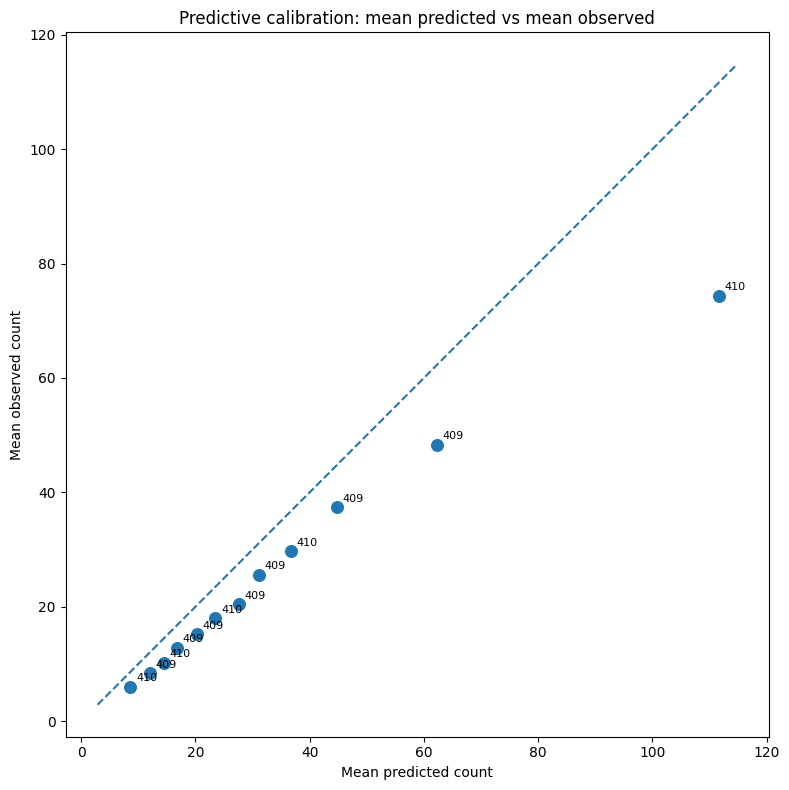

In [22]:


# y_pp_model2 was created above with shape (n_days, S)
y_true = daily_cmp_2025_model2['daily_count'].to_numpy()
y_pred_draws = np.asarray(y_pp_model2)
if y_pred_draws.shape[0] != len(y_true):
    y_pred_draws = y_pred_draws.T

# ----- 1) Mean calibration by prediction bin -----
pred_mean = y_pred_draws.mean(axis=1)
calib_df = pd.DataFrame({
    'y_true': y_true,
    'pred_mean': pred_mean,
}).dropna().copy()

n_bins = min(12, calib_df['pred_mean'].nunique())
calib_df['bin'] = pd.qcut(calib_df['pred_mean'], q=n_bins, duplicates='drop')

calib_summary = (
    calib_df.groupby('bin', observed=False)
    .agg(
        pred_mean=('pred_mean', 'mean'),
        obs_mean=('y_true', 'mean'),
        n=('y_true', 'size')
    )
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 8))
plt.scatter(calib_summary['pred_mean'], calib_summary['obs_mean'], s=70)
for _, row in calib_summary.iterrows():
    plt.annotate(int(row['n']), (row['pred_mean'], row['obs_mean']), xytext=(4, 4), textcoords='offset points', fontsize=8)

min_val = min(calib_summary['pred_mean'].min(), calib_summary['obs_mean'].min())
max_val = max(calib_summary['pred_mean'].max(), calib_summary['obs_mean'].max())
pad = max(2, (max_val - min_val) * 0.03)
plt.plot([min_val - pad, max_val + pad], [min_val - pad, max_val + pad], '--')
plt.xlabel('Mean predicted count')
plt.ylabel('Mean observed count')
plt.title('Predictive calibration: mean predicted vs mean observed')
plt.tight_layout()
plt.show()



This table shows how well the model’s prediction intervals match reality.

* **Nominal coverage**
  What the model *claims* (e.g., a 90% interval should contain the true value 90% of the time)

* **Empirical coverage**
  What actually happens in the data

* **Mean / median interval width**
  How wide the prediction ranges are

  * Wider = more uncertainty
  * Narrower = more confidence

---

For example:

* At the **50% interval**, the model only captures about **20%** of actual outcomes
* At the **95% interval**, it captures only about **49%**

---

**What this means:**
The intervals are too narrow and miss the true values far more often than expected.


In short, the model is **overconfident** — it underestimates uncertainty, especially in higher-count areas.


In [23]:

# ----- 2) Interval calibration -----
levels = np.array([0.5, 0.8, 0.9, 0.95])
rows = []
for level in levels:
    alpha = 1 - level
    lo = np.quantile(y_pred_draws, alpha / 2, axis=1)
    hi = np.quantile(y_pred_draws, 1 - alpha / 2, axis=1)
    covered = ((y_true >= lo) & (y_true <= hi)).mean()
    rows.append({
        'nominal_coverage': level,
        'empirical_coverage': covered,
        'mean_interval_width': float(np.mean(hi - lo)),
        'median_interval_width': float(np.median(hi - lo)),
    })

interval_calib = pd.DataFrame(rows)

interval_calib

,nominal_coverage,empirical_coverage,mean_interval_width,median_interval_width
0,0.50,0.194382,7.438072,7.0
1,0.80,0.335844,14.106513,13.0
2,0.90,0.419296,18.099725,17.0
3,0.95,0.488703,21.525738,20.0
